In [30]:
import sys
import os

while not os.path.isdir("src") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.simulator import PortfolioSimulator
from tradinglab.backtester import run_backtest
from tradinglab.strategies.sma import sma_crossover_weights
from tradinglab.charting import turnover_summary

In [31]:
feed = DataFeed.from_dir(
    "data/egx",
    symbols=[
        "COMI",
        "HRHO",
        "TMGH",
        "SWDY",
        "FWRY",
        "ABUK"
    ]
)

print(
    "Universe:",
    feed.symbols,
    "| Days:",
    feed.n_days
)

Universe: ['COMI', 'HRHO', 'TMGH', 'SWDY', 'FWRY', 'ABUK'] | Days: 1693


In [32]:
sim = PortfolioSimulator(feed)

print("Simulator created successfully.")

Simulator created successfully.


In [33]:
def momentum_sma_weights(
    observation,
    sma_window=20,
    momentum_window=5
):
    """
    New Strategy:
    
    A stock is selected when:
        1. Current close price > SMA20
        2. 5-day momentum > 0

    Selected stocks receive equal weights.

    If no stock qualifies, hold cash.
    """

    observation = np.asarray(
        observation,
        dtype=float
    )

    # Expected shape:
    # (number_of_stocks, lookback_days, features)
    n_assets, n_days, n_features = observation.shape

    # --------------------------------------------------
    # Feature index
    # --------------------------------------------------
    #
    # We need the CLOSE price.
    #
    # Your observation has 5 features.
    # In TradingLab's OHLCV-style observation,
    # close is feature index 3.
    #
    CLOSE_INDEX = 3

    prices = observation[:, :, CLOSE_INDEX]

    # prices shape:
    #
    # (6, 30)
    #
    # 6 stocks
    # 30 historical days

    # --------------------------------------------------
    # Check enough history
    # --------------------------------------------------

    if n_days < max(
        sma_window,
        momentum_window + 1
    ):
        return np.zeros(n_assets)

    # --------------------------------------------------
    # Current prices
    # --------------------------------------------------

    current_prices = prices[:, -1]

    # --------------------------------------------------
    # SMA20
    # --------------------------------------------------

    sma20 = np.mean(
        prices[:, -sma_window:],
        axis=1
    )

    # --------------------------------------------------
    # 5-day momentum
    # --------------------------------------------------

    previous_prices = prices[
        :,
        -(momentum_window + 1)
    ]

    momentum = (
        current_prices / previous_prices
    ) - 1

    # --------------------------------------------------
    # Strategy conditions
    # --------------------------------------------------

    above_sma = (
        current_prices > sma20
    )

    positive_momentum = (
        momentum > 0
    )

    selected = (
        above_sma
        &
        positive_momentum
    )

    # --------------------------------------------------
    # Create weights
    # --------------------------------------------------

    weights = np.zeros(
        n_assets,
        dtype=float
    )

    number_selected = np.sum(
        selected
    )

    # Equal weight selected stocks
    if number_selected > 0:

        weights[selected] = (
            1.0 / number_selected
        )

    return weights

In [34]:
test_weights = momentum_sma_weights(obs)

print("Weights:", test_weights)
print("Number of stocks:", len(test_weights))
print("Weight sum:", test_weights.sum())

Weights: [0. 0. 1. 0. 0. 0.]
Number of stocks: 6
Weight sum: 1.0


In [35]:
test_weights = momentum_sma_weights(obs)

print("Weights:")
print(test_weights)

print("Number of stocks:", len(test_weights))
print("Sum of weights:", test_weights.sum())

Weights:
[0. 0. 1. 0. 0. 0.]
Number of stocks: 6
Sum of weights: 1.0


In [36]:
from tradinglab.backtester import build_observation

# Create the same type of observation
# that run_backtest() gives to the strategy
test_observation = build_observation(
    feed,
    30,
    30
)

print("Observation shape:", test_observation.shape)

weights = momentum_sma_weights(
    test_observation
)

print("Weights:")
print(weights)

print("Number of stocks:", len(weights))

print("Sum of weights:", weights.sum())

Observation shape: (6, 30, 5)
Weights:
[0. 0. 1. 0. 0. 0.]
Number of stocks: 6
Sum of weights: 1.0


In [37]:
new_result = run_backtest(
    sim,
    momentum_sma_weights,
    lookback=30
)

print("Backtest completed.")

print(
    "Portfolio length:",
    len(new_result["portfolio"])
)

print(
    "Final normalized portfolio:",
    round(
        new_result["portfolio"][-1],
        3
    )
)

Backtest completed.
Portfolio length: 1662
Final normalized portfolio: 16.937


C:\Users\menna\AppData\Local\Temp\ipykernel_9024\2100741439.py:83: RuntimeWarning: divide by zero encountered in divide
  current_prices / previous_prices


In [38]:
START_CAPITAL = 1000.0

new_curve = (
    new_result["portfolio"]
    * START_CAPITAL
)

print(
    "Final portfolio value:",
    round(
        new_curve[-1],
        2
    ),
    "EGP"
)

Final portfolio value: 16936.52 EGP


In [39]:
def total_return(returns):

    return float(
        np.prod(
            1 + np.asarray(returns)
        ) - 1
    )


new_total_return = total_return(
    new_result["portfolio_returns"]
)

print(
    f"Total return: {new_total_return:.2%}"
)

Total return: 1593.65%


In [40]:
def total_return(returns):

    return float(
        np.prod(
            1 + np.asarray(returns)
        ) - 1
    )


new_total_return = total_return(
    new_result["portfolio_returns"]
)

print(
    f"Total return: {new_total_return:.2%}"
)

Total return: 1593.65%


In [41]:
def max_drawdown(returns):

    curve = np.cumprod(
        1 + np.asarray(returns)
    )

    peak = np.maximum.accumulate(
        curve
    )

    drawdown = (
        peak - curve
    ) / peak

    return float(
        np.max(drawdown)
    )


new_max_dd = max_drawdown(
    new_result["portfolio_returns"]
)

print(
    f"Maximum drawdown: {new_max_dd:.2%}"
)

Maximum drawdown: 29.54%


In [42]:
summary = turnover_summary(
    new_result["weights"]
)

print(
    "Total trades:",
    summary["total_trades"]
)

print(
    "Average stocks held:",
    round(
        summary["avg_stocks_held"],
        2
    )
)

Total trades: 2969
Average stocks held: 2.26


In [43]:
summary = turnover_summary(
    new_result["weights"]
)

print(
    "Total trades:",
    summary["total_trades"]
)

print(
    "Average stocks held:",
    round(
        summary["avg_stocks_held"],
        2
    )
)

Total trades: 2969
Average stocks held: 2.26


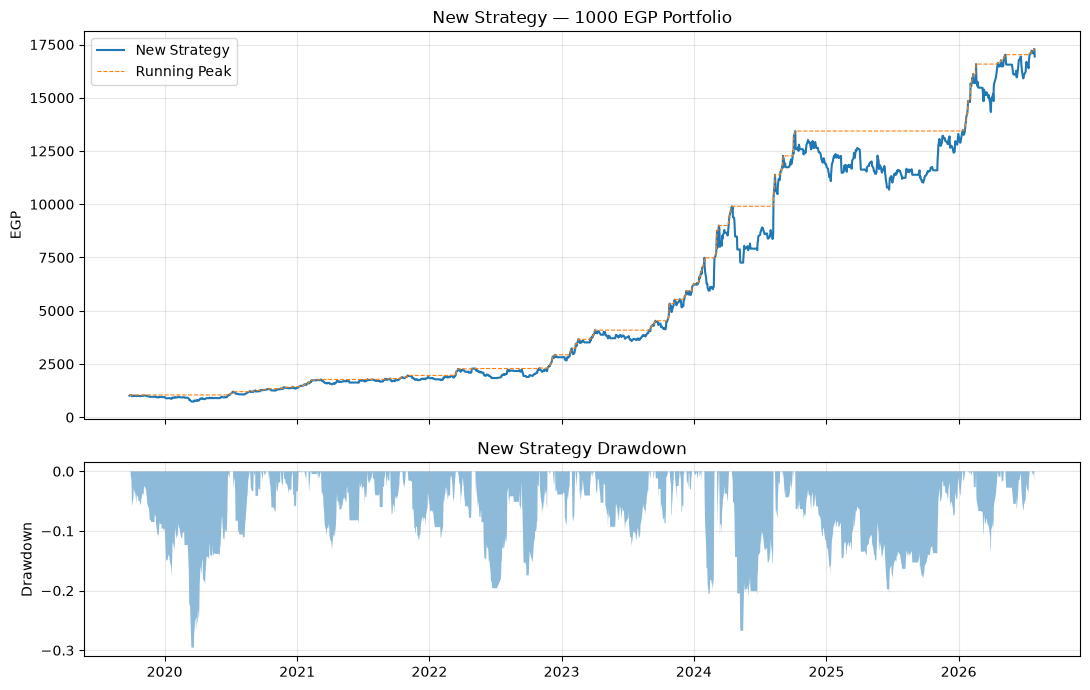

In [44]:
dates = new_result["dates"]

curve = (
    new_result["portfolio"]
    * START_CAPITAL
)

peak = np.maximum.accumulate(
    curve
)

drawdown_series = (
    peak - curve
) / peak


fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2, 1]
    }
)


# ------------------------------------------------------------
# Portfolio
# ------------------------------------------------------------

ax1.plot(
    dates,
    curve,
    label="New Strategy"
)

ax1.plot(
    dates,
    peak,
    "--",
    label="Running Peak",
    linewidth=0.8
)

ax1.set_title(
    "New Strategy — 1000 EGP Portfolio"
)

ax1.set_ylabel("EGP")

ax1.legend()

ax1.grid(alpha=0.3)


# ------------------------------------------------------------
# Drawdown
# ------------------------------------------------------------

ax2.fill_between(
    dates,
    -drawdown_series,
    0,
    alpha=0.5
)

ax2.set_title(
    "New Strategy Drawdown"
)

ax2.set_ylabel("Drawdown")

ax2.grid(alpha=0.3)


plt.tight_layout()

plt.show()

In [45]:
base_result = run_backtest(
    sim,
    lambda observation:
        sma_crossover_weights(
            observation,
            9,
            20
        ),
    lookback=30
)

print(
    "Base SMA 9/20 backtest completed."
)

Base SMA 9/20 backtest completed.


In [46]:
base_total_return = total_return(
    base_result["portfolio_returns"]
)

base_max_dd = max_drawdown(
    base_result["portfolio_returns"]
)

base_r = np.asarray(
    base_result["portfolio_returns"],
    dtype=float
)

if (
    len(base_r) > 1
    and np.std(base_r) > 0
):

    base_sharpe = (
        np.mean(base_r)
        / np.std(base_r)
    ) * np.sqrt(252)

else:

    base_sharpe = 0.0


base_final_value = (
    base_result["portfolio"][-1]
    * START_CAPITAL
)


print(
    f"Base final value: "
    f"{base_final_value:.2f} EGP"
)

print(
    f"Base total return: "
    f"{base_total_return:.2%}"
)

print(
    f"Base max drawdown: "
    f"{base_max_dd:.2%}"
)

print(
    f"Base Sharpe: "
    f"{base_sharpe:.3f}"
)

Base final value: 5807.42 EGP
Base total return: 480.74%
Base max drawdown: 37.79%
Base Sharpe: 1.047


In [48]:
# New strategy Sharpe ratio

new_r = np.asarray(
    new_result["portfolio_returns"],
    dtype=float
)

if len(new_r) > 1 and np.std(new_r) > 0:

    new_sharpe = (
        np.mean(new_r)
        / np.std(new_r)
    ) * np.sqrt(252)

else:

    new_sharpe = 0.0

print(f"New Strategy Sharpe Ratio: {new_sharpe:.3f}")

New Strategy Sharpe Ratio: 1.610


In [49]:
comparison = pd.DataFrame({

    "Metric": [
        "Final Portfolio Value",
        "Total Return",
        "Maximum Drawdown",
        "Sharpe Ratio",
        "Total Trades"
    ],

    "Base Strategy — SMA 9/20": [

        base_final_value,

        base_total_return * 100,

        base_max_dd * 100,

        base_sharpe,

        turnover_summary(
            base_result["weights"]
        )["total_trades"]
    ],

    "New Strategy — SMA20 + Momentum": [

        new_curve[-1],

        new_total_return * 100,

        new_max_dd * 100,

        new_sharpe,

        summary["total_trades"]
    ]
})

comparison

,Metric,Base Strategy — SMA 9/20,New Strategy — SMA20 + Momentum
0,Final Portfolio Value,5807.422744,16936.521729
1,Total Return,480.742274,1593.652173
2,Maximum Drawdown,37.787230,29.541757
3,Sharpe Ratio,1.047135,1.610107
4,Total Trades,1678.000000,2969.000000


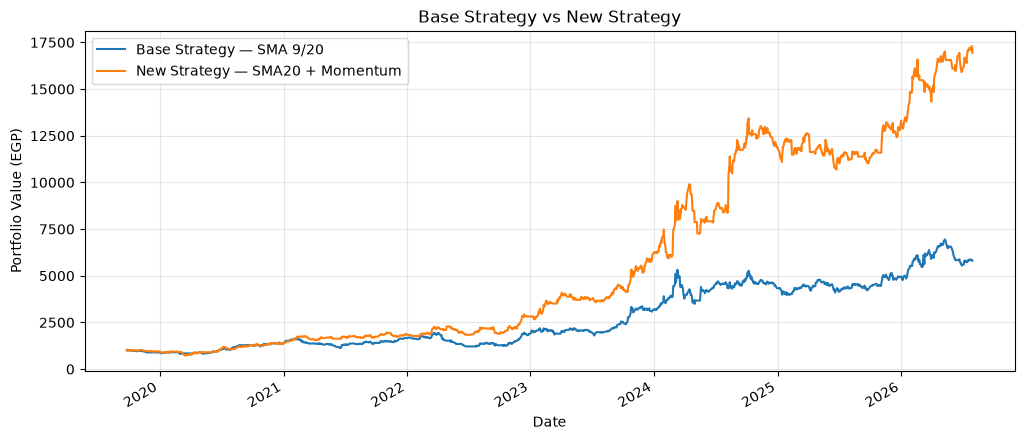

In [50]:
base_curve = (
    base_result["portfolio"]
    * START_CAPITAL
)

new_curve = (
    new_result["portfolio"]
    * START_CAPITAL
)

dates = base_result["dates"]


plt.figure(figsize=(12, 5))

plt.plot(
    dates,
    base_curve,
    label="Base Strategy — SMA 9/20"
)

plt.plot(
    dates,
    new_curve,
    label="New Strategy — SMA20 + Momentum"
)

plt.title(
    "Base Strategy vs New Strategy"
)

plt.xlabel("Date")

plt.ylabel(
    "Portfolio Value (EGP)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.gcf().autofmt_xdate()

plt.show()

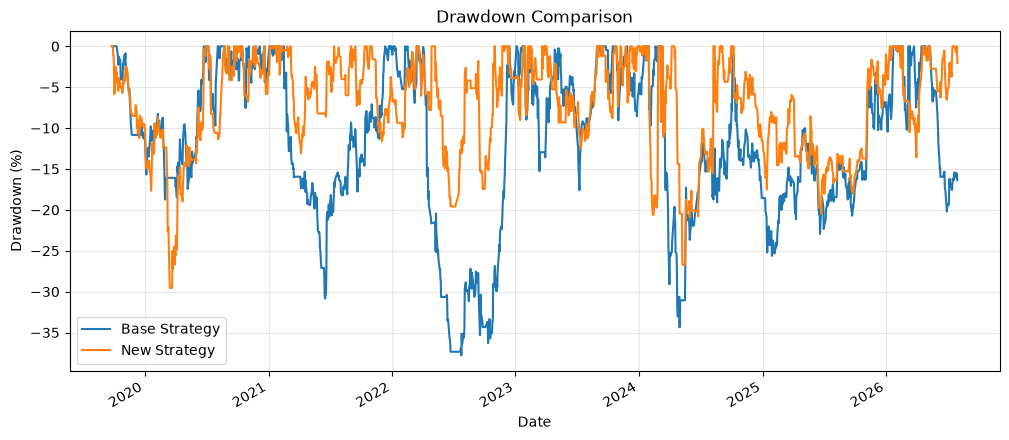

In [51]:
base_returns = np.asarray(
    base_result["portfolio_returns"]
)

new_returns = np.asarray(
    new_result["portfolio_returns"]
)


base_equity = np.cumprod(
    1 + base_returns
)

new_equity = np.cumprod(
    1 + new_returns
)


base_peak = np.maximum.accumulate(
    base_equity
)

new_peak = np.maximum.accumulate(
    new_equity
)


base_dd = (
    base_peak - base_equity
) / base_peak

new_dd = (
    new_peak - new_equity
) / new_peak


plt.figure(figsize=(12, 5))

plt.plot(
    dates,
    -base_dd * 100,
    label="Base Strategy"
)

plt.plot(
    dates,
    -new_dd * 100,
    label="New Strategy"
)

plt.title(
    "Drawdown Comparison"
)

plt.xlabel("Date")

plt.ylabel(
    "Drawdown (%)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.gcf().autofmt_xdate()

plt.show()

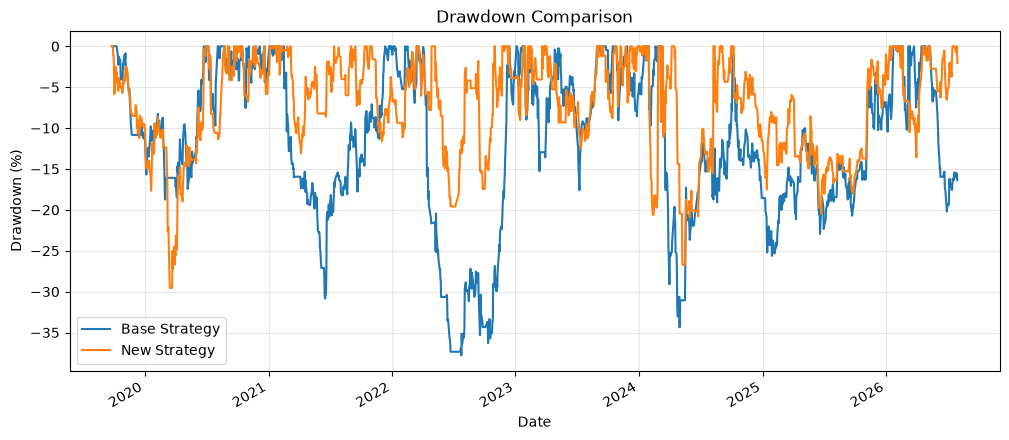

In [52]:
base_returns = np.asarray(
    base_result["portfolio_returns"]
)

new_returns = np.asarray(
    new_result["portfolio_returns"]
)


base_equity = np.cumprod(
    1 + base_returns
)

new_equity = np.cumprod(
    1 + new_returns
)


base_peak = np.maximum.accumulate(
    base_equity
)

new_peak = np.maximum.accumulate(
    new_equity
)


base_dd = (
    base_peak - base_equity
) / base_peak

new_dd = (
    new_peak - new_equity
) / new_peak


plt.figure(figsize=(12, 5))

plt.plot(
    dates,
    -base_dd * 100,
    label="Base Strategy"
)

plt.plot(
    dates,
    -new_dd * 100,
    label="New Strategy"
)

plt.title(
    "Drawdown Comparison"
)

plt.xlabel("Date")

plt.ylabel(
    "Drawdown (%)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.gcf().autofmt_xdate()

plt.show()